In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [3]:
!pip install --upgrade networkx
!pip install scanpy
!pip install SCORED

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.3/169.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 6.7 MB/s eta 0:00:00


In [4]:
import sklearn
import scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
from scipy.stats import spearmanr
import numpy as np
import torch
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
from anndata import AnnData
from typing import Optional, List
from scored import SCORED


In [5]:
def read_data(flowcell, dataset):
    adata_raw = sc.read_h5ad(
        f"./{dataset}_new/transcript_raw_{flowcell}.h5ad"
    )
    adata_refined = sc.read_h5ad(
        f"./{dataset}_new/transcript_new_{flowcell}.h5ad"
    )
    pseudotime_metadata = pd.read_csv(
        f'./{dataset}_new/meta_data_pseudotime.csv',
        index_col=0
    )

    adata_raw = adata_raw[adata_raw.obs.index.isin(pseudotime_metadata['cell_names'])]
    sc.pp.normalize_total(adata_raw, target_sum=1e4)

    adata_raw.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_raw.obs.index].values

    adata_refined = adata_refined[adata_refined.obs.index.isin(pseudotime_metadata['cell_names'])]
    adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values

    return adata_raw, adata_refined, pseudotime_metadata


In [6]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

def plot_isoform_expression_and_regression(adata_raw, adata_refined, isoform_names):

    fig, axs = plt.subplots(2, len(isoform_names), figsize=(2 * len(isoform_names), 6), dpi=256, sharex=True, sharey=True)

    adata_raw.var["mt"] = adata_raw.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata_raw, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
    )
    sc.pp.normalize_total(adata_raw, target_sum=1e4)
    for i, isoform_name in enumerate(isoform_names):

        raw_expr = np.log1p(adata_raw[:, isoform_name].X.toarray().reshape(-1))
        #refined_expr = np.log1p(adata_refined[:, isoform_name].X.toarray().reshape(-1))
        refined_expr = adata_refined[:, isoform_name].X.toarray().reshape(-1)
        pseudotime = adata_raw.obs['pseudotime'].to_numpy()

        raw_lowess_result = sm.nonparametric.lowess(raw_expr, pseudotime, frac=0.6)
        refined_lowess_result = sm.nonparametric.lowess(refined_expr, pseudotime, frac=0.6)

        axs[0,i].scatter(pseudotime, raw_expr, color='tab:blue', alpha=0.2, label='Raw Expression')
        axs[0,i].plot(raw_lowess_result[:, 0], raw_lowess_result[:, 1], color='tab:orange', label='LOWESS')


        axs[1,i].scatter(pseudotime, refined_expr, color='tab:green', alpha=0.2, label='Refined Expression')
        axs[1,i].plot(refined_lowess_result[:, 0], refined_lowess_result[:, 1], color='tab:orange', label='LOWESS')

        axs[0,i].spines['right'].set_visible(False)
        axs[0,i].spines['top'].set_visible(False)
        axs[1,i].spines['right'].set_visible(False)
        axs[1,i].spines['top'].set_visible(False)

        axs[0,i].set_title(isoform_name)
        axs[1,i].set_xlabel('Pseudotime')

    axs[0,0].set_ylabel(f'Raw - log(Expression)')
    axs[1,0].set_ylabel(f'Refined - log(Expression)')
    axs[0,len(isoform_names)-1].legend(loc='center left', bbox_to_anchor=(1.2, 1))
    axs[1,len(isoform_names)-1].legend(loc='center left', bbox_to_anchor=(1.2, 1))

    plt.show()


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_isoform_2x2(
    adata_dict, isoform, ylim=None, xlim=None,
    drop_top_pct=0.05, use_global_cut=True, sharey=False
):
    colors = {'with_pge2': '#E41A1C', 'no_pge2': '#377EB8'}
    conds  = ['no_pge2', 'with_pge2']
    phases = ['raw', 'refined']

    phase_labels = {'raw': 'Original', 'refined': 'Refined'}
    cond_labels  = {'with_pge2': 'IL1B+IL23+PGE2', 'no_pge2': 'IL1B+IL23'}

    all_x = []
    for cond in conds:
        adata_raw, adata_refined = adata_dict[cond]
        all_x.append(adata_raw.obs['pseudotime'])
        all_x.append(adata_refined.obs['pseudotime'])
    all_x = pd.concat(all_x)

    if xlim is None:
        xmin = float(all_x.min())
        xmax_base = float(all_x.max())
        if drop_top_pct and use_global_cut:
            xmax = float(all_x.quantile(1 - drop_top_pct))
        else:
            xmax = xmax_base
        xlim = (xmin, xmax)

    fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=200, sharex=True, sharey=sharey)

    for i, phase in enumerate(phases):
        for j, cond in enumerate(conds):
            ax = axes[i, j]
            adata_raw, adata_refined = adata_dict[cond]
            adata = adata_raw if phase == 'raw' else adata_refined

            if isoform not in adata.var_names:
                ax.text(0.5, 0.5, f"{isoform} not found", ha='center', va='center')
                ax.set_axis_off()
                continue

            x_series = adata.obs['pseudotime']
            if drop_top_pct:
                cutoff = xlim[1] if use_global_cut else float(x_series.quantile(1 - drop_top_pct))
                mask = x_series <= cutoff
                ad = adata[mask].copy()
            else:
                ad = adata

            expr = ad.obs_vector(isoform)
            if phase == 'raw':
                expr = np.log1p(expr)
            x = ad.obs['pseudotime'].to_numpy()

            sns.scatterplot(x=x, y=expr, ax=ax, s=5, color=colors[cond],
                            alpha=0.3, linewidth=0, zorder=1)
            sns.kdeplot(x=x, y=expr, ax=ax, fill=True,
                        levels=5, thresh=0.05, cut=0,
                        color=colors[cond], alpha=0.6)

            base_rgb = mcolors.to_rgb(colors[cond])
            darker_hex = mcolors.to_hex(tuple(c*0.6 for c in base_rgb))
            sns.regplot(x=x, y=expr, ax=ax, scatter=False, lowess=True,
                        line_kws={'color': darker_hex})

            ax.set_title(f"{phase_labels[phase]} - {cond_labels[cond]}")
            ax.set_ylabel(f"{isoform} Expression")
            ax.set_xlim(xlim)
            if ylim:
                ax.set_ylim(ylim)

    for ax in axes.flat:
        ax.set_xlabel('Pseudotime')
    for ax in axes[0, :]:
        ax.tick_params(labelbottom=True)
        ax.xaxis.label.set_visible(True)
        ax.xaxis.set_label_position('bottom')
        ax.xaxis.labelpad = 6

    plt.tight_layout()
    plt.show()


8fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


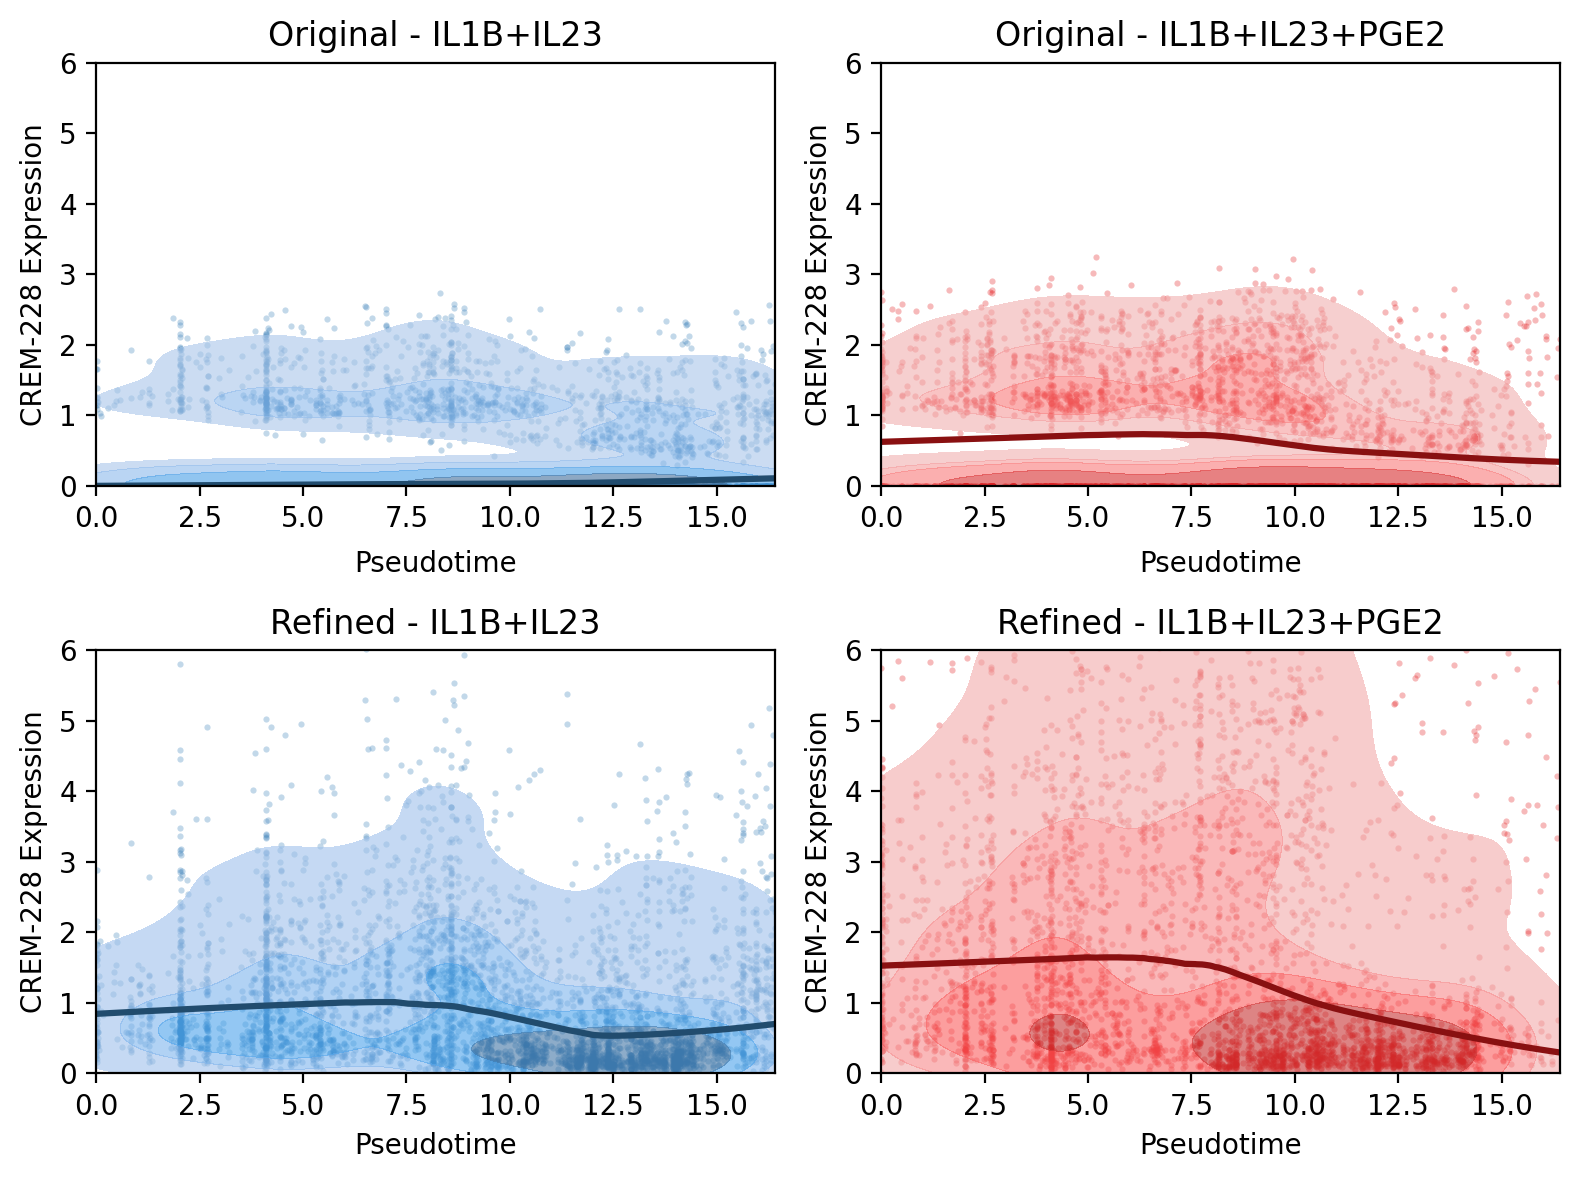

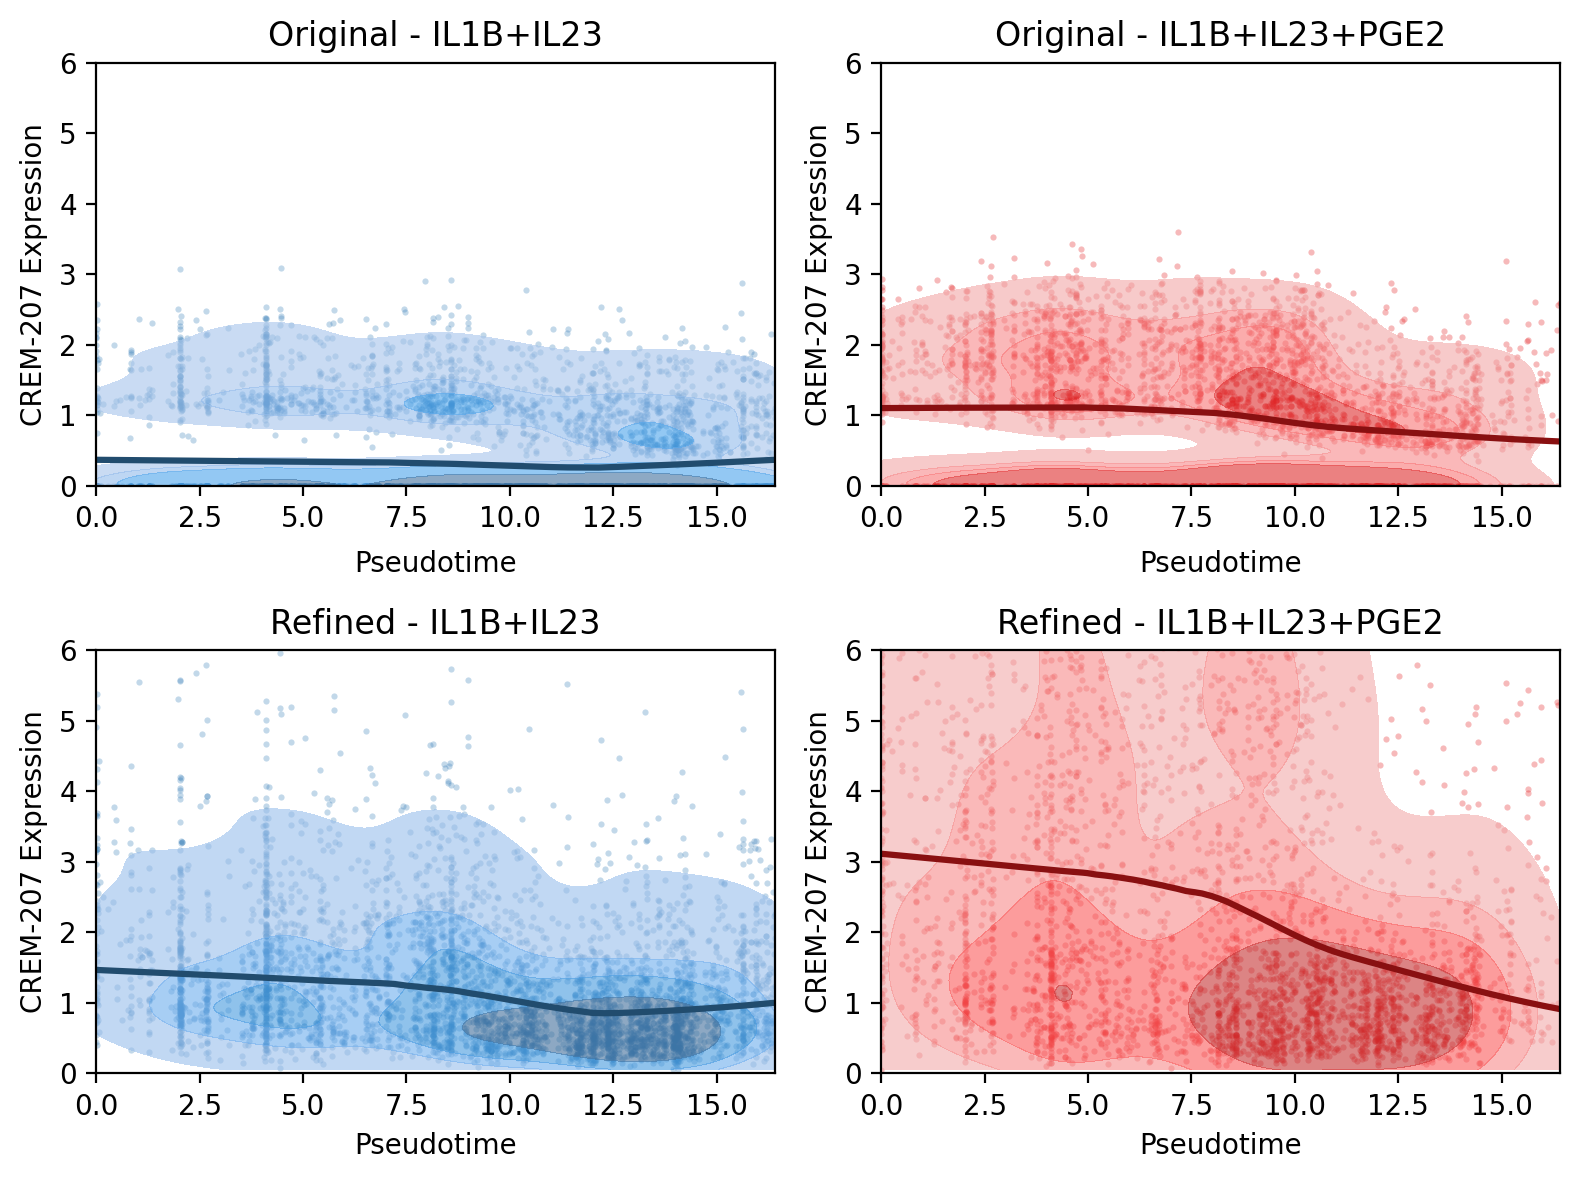

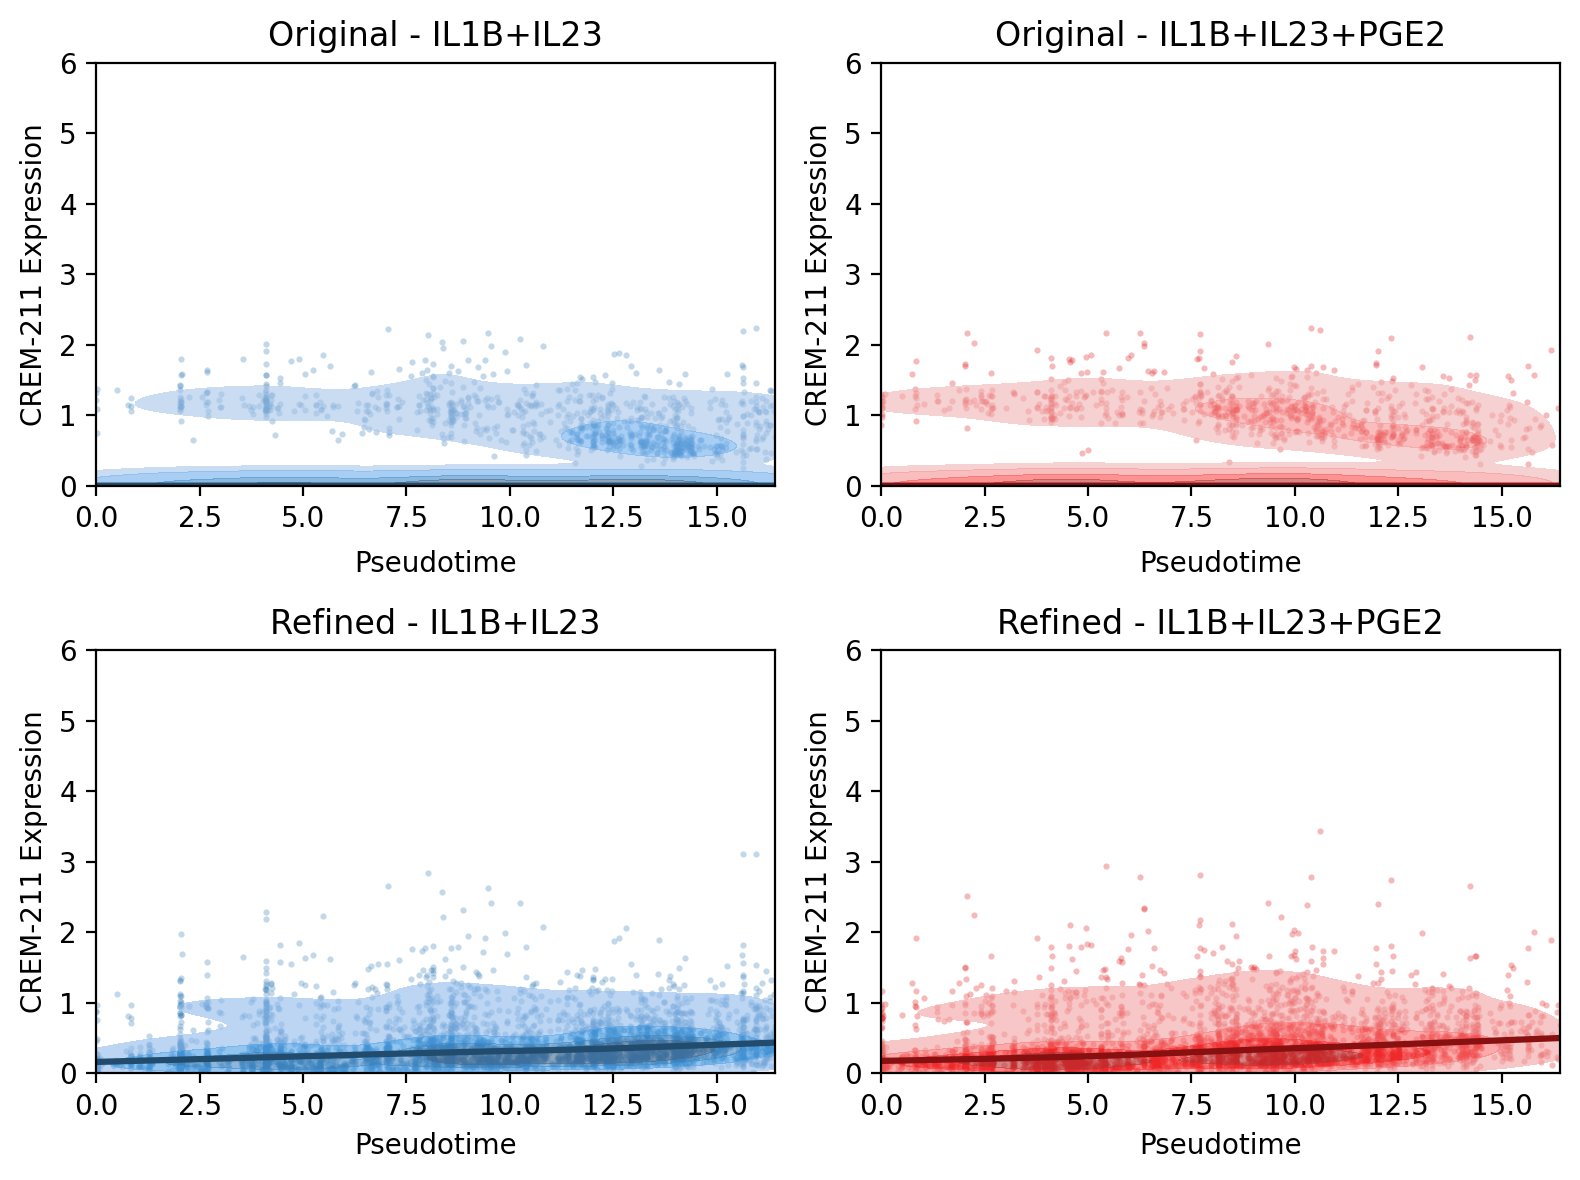

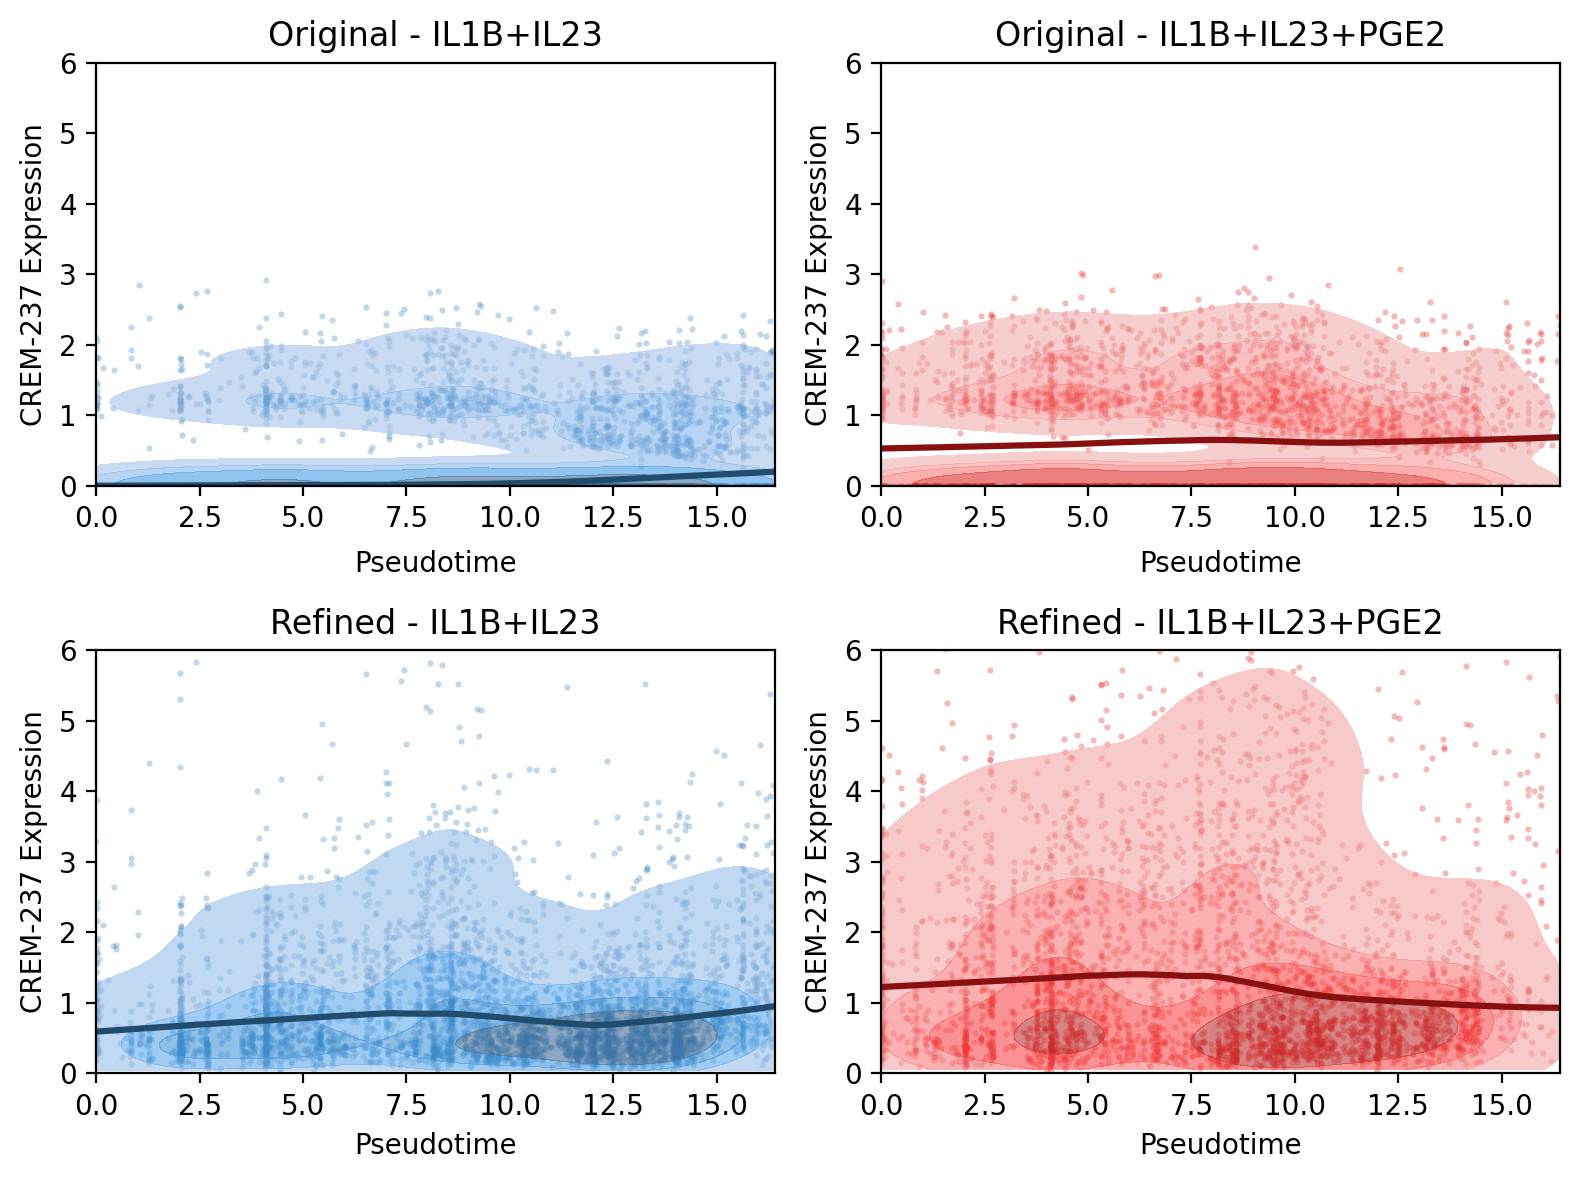

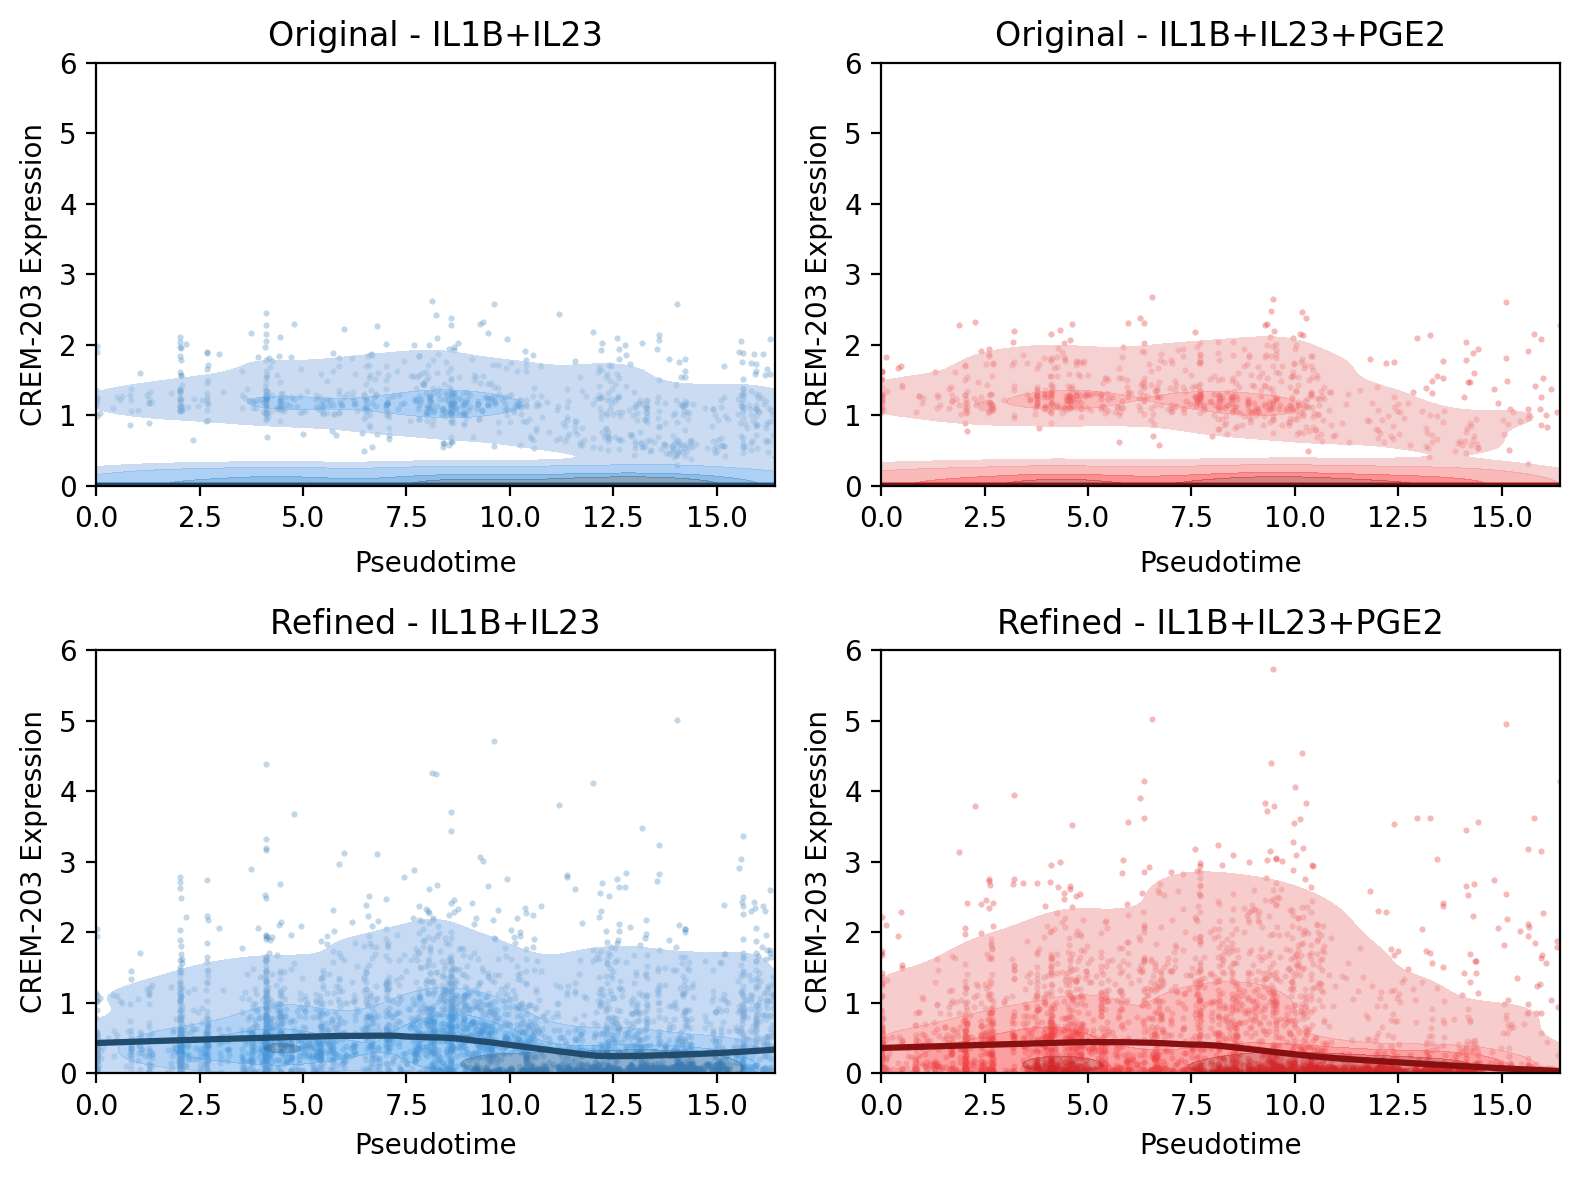

In [8]:
adata_raw, adata_refined, pseudotime_metadata = read_data('8fc', '20230614')

# subset where condition_time ends with "PGE2"
adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time ends with "PGE2"
adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))

4fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


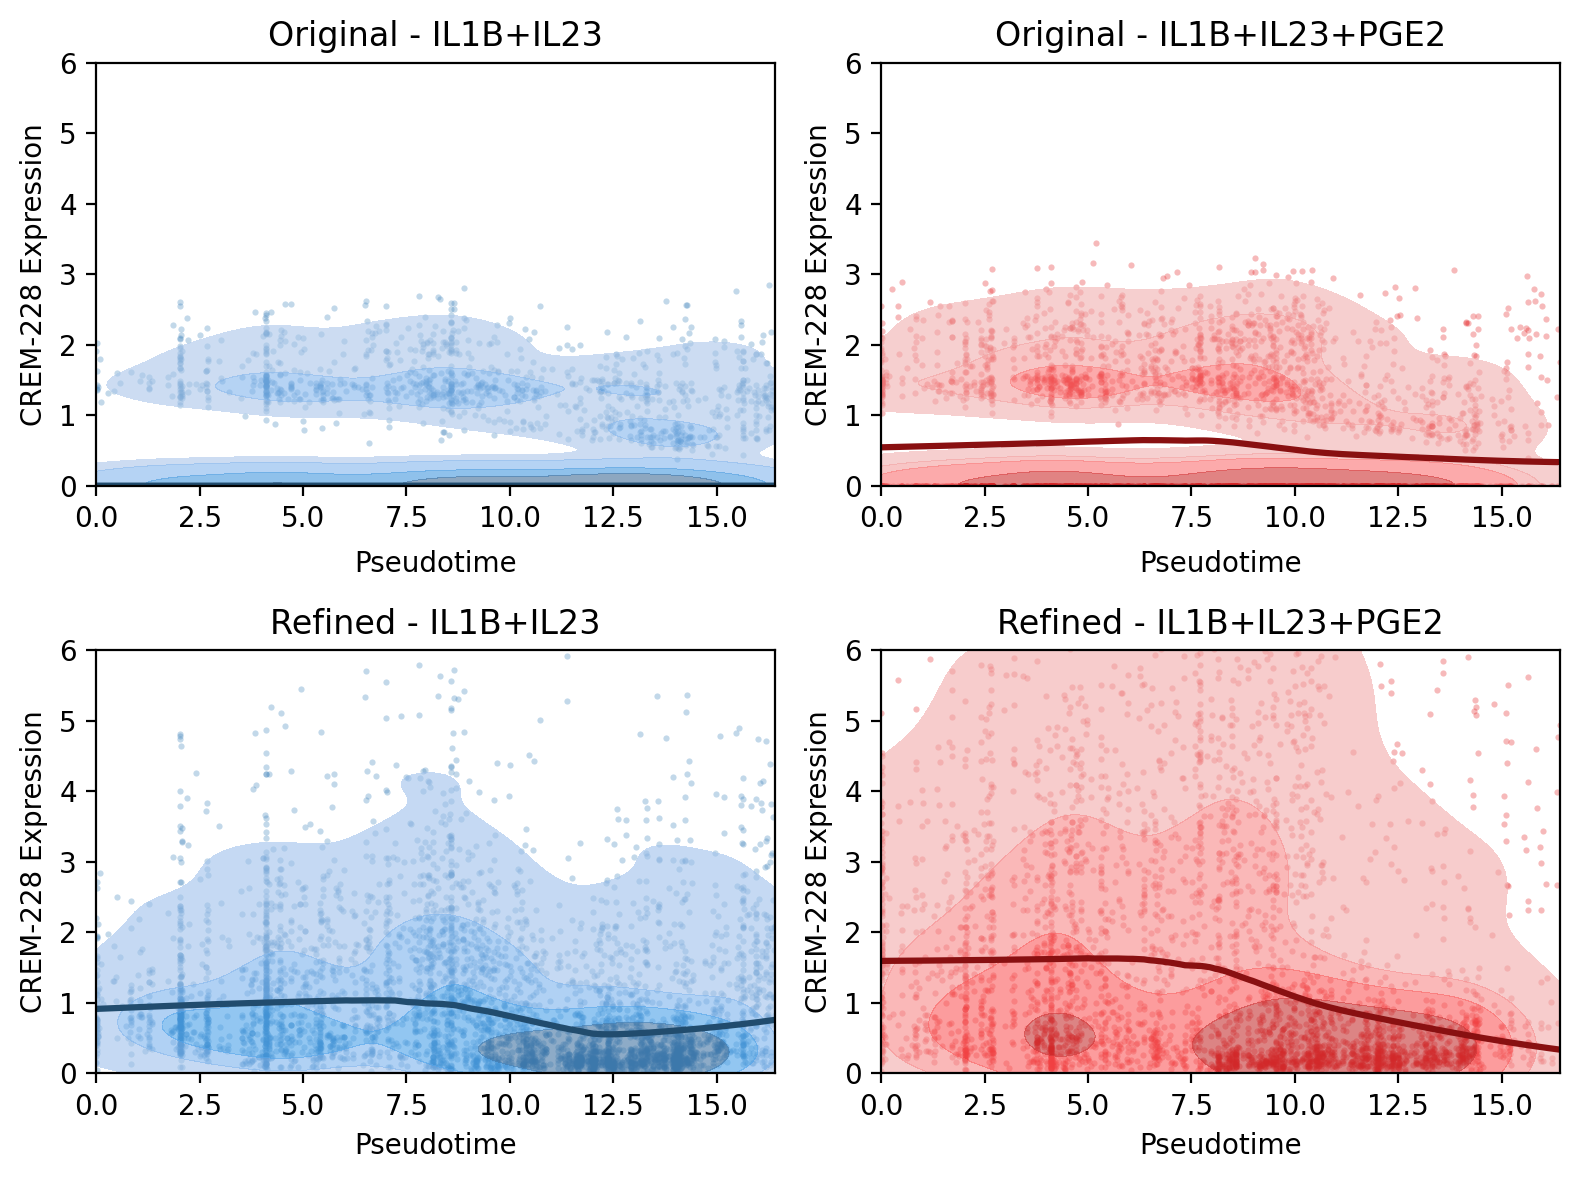

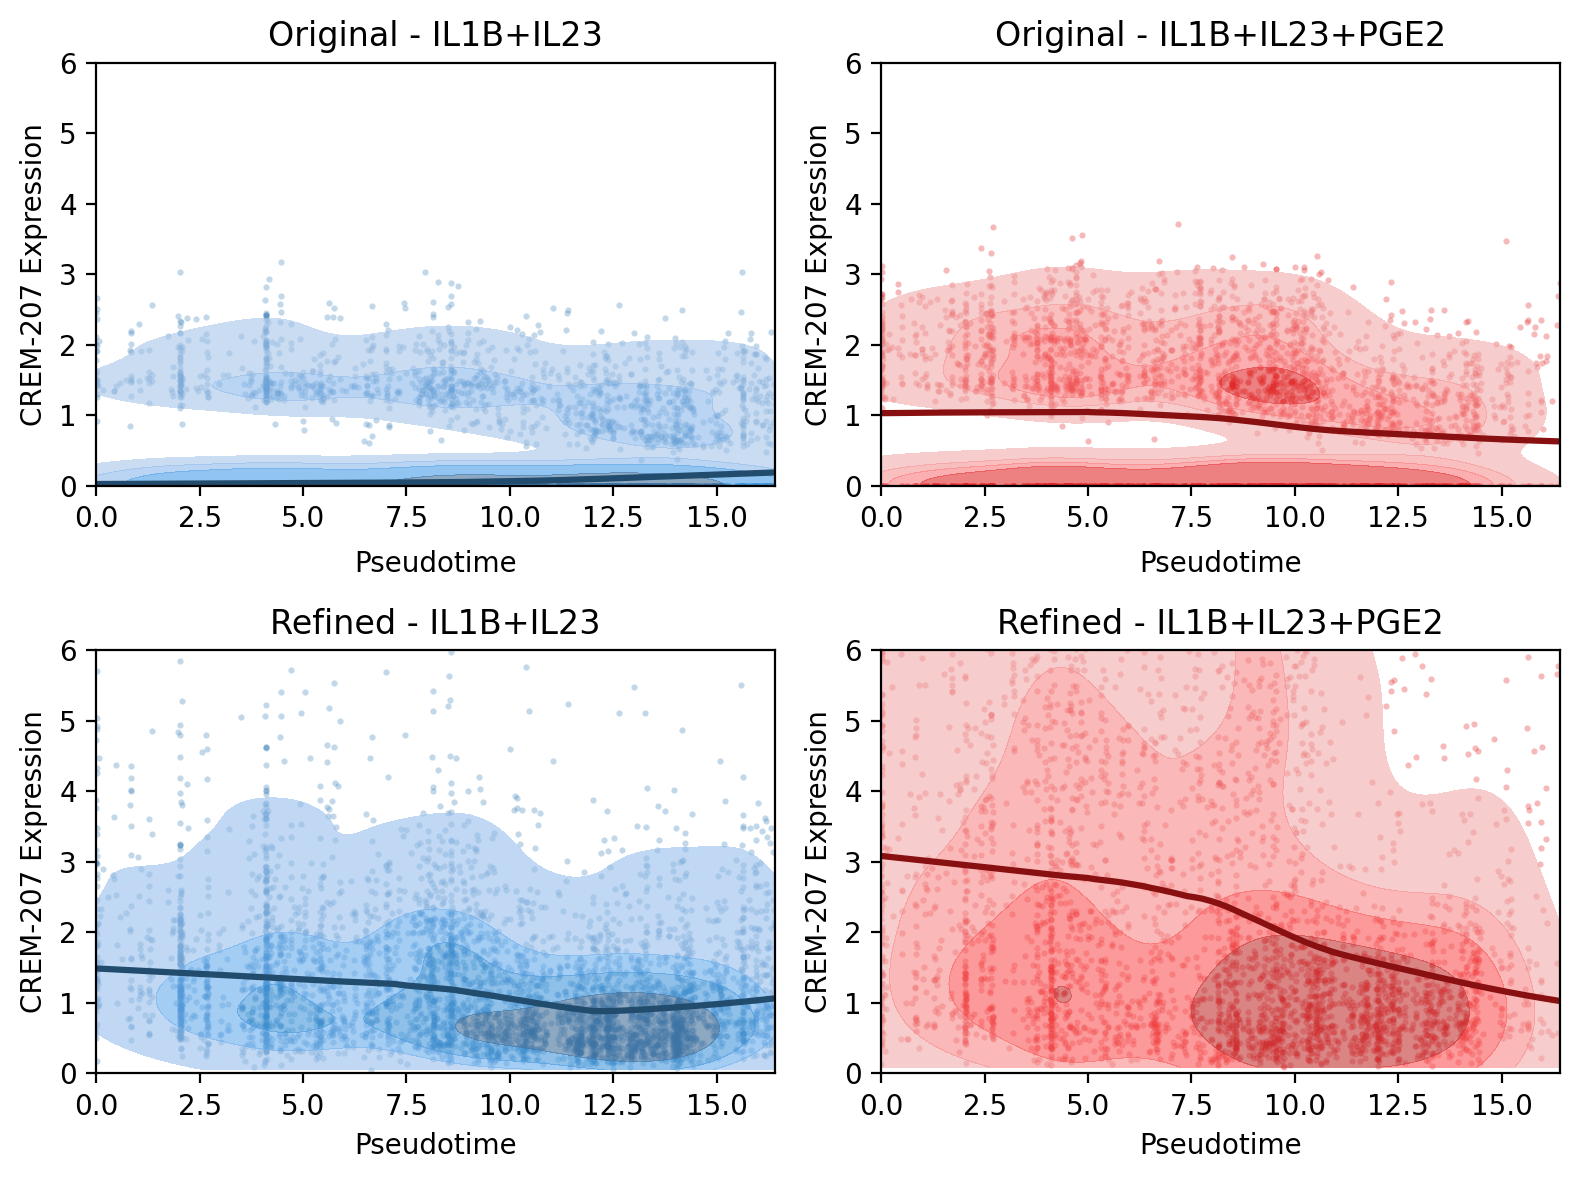

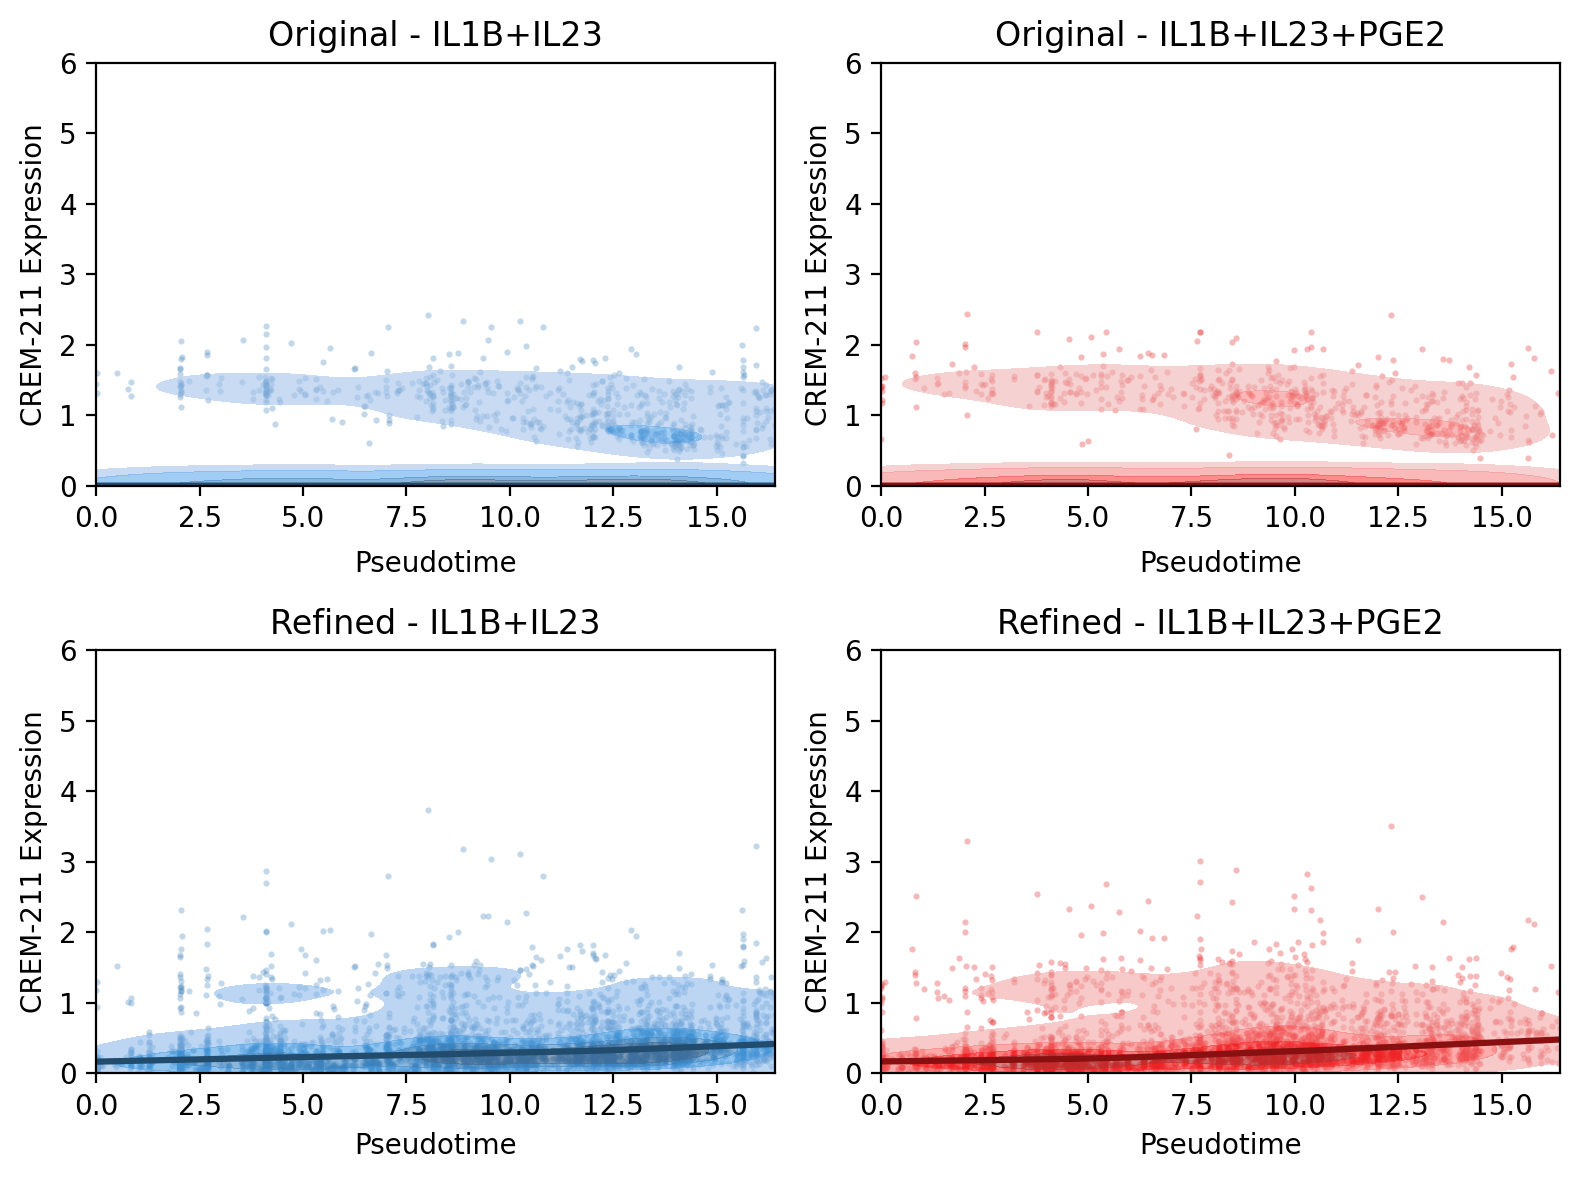

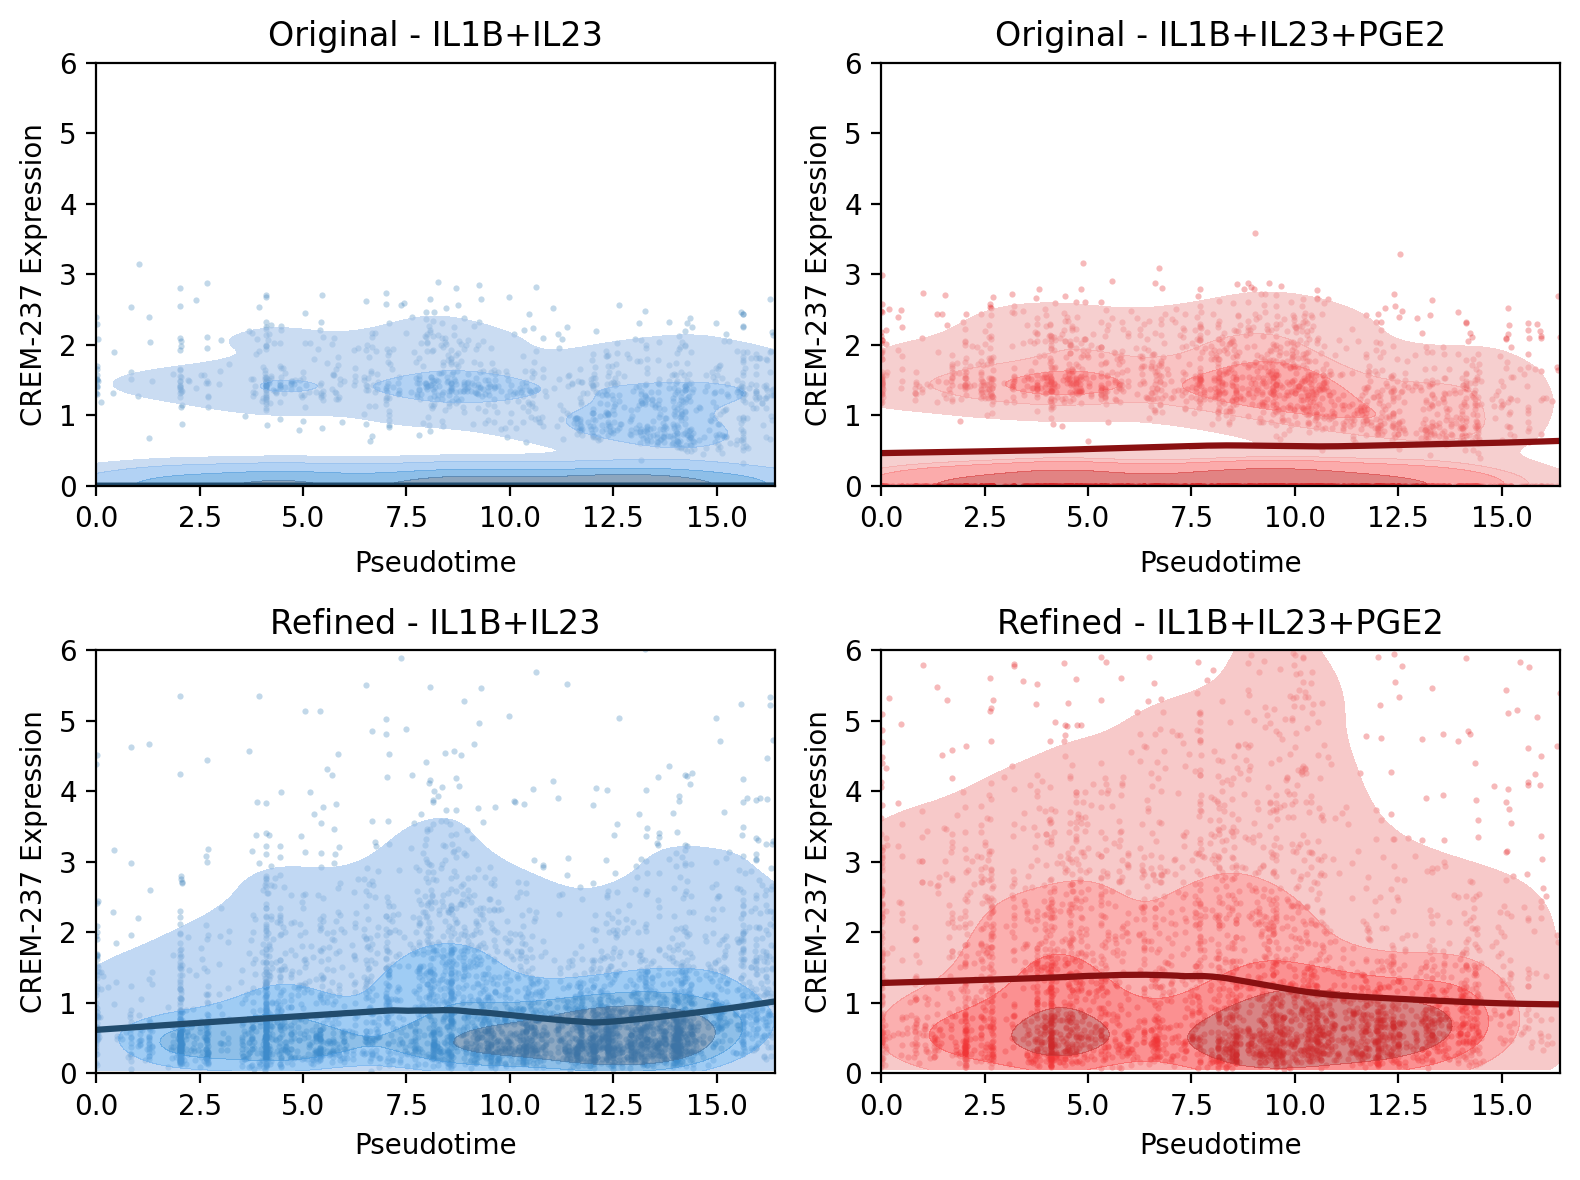

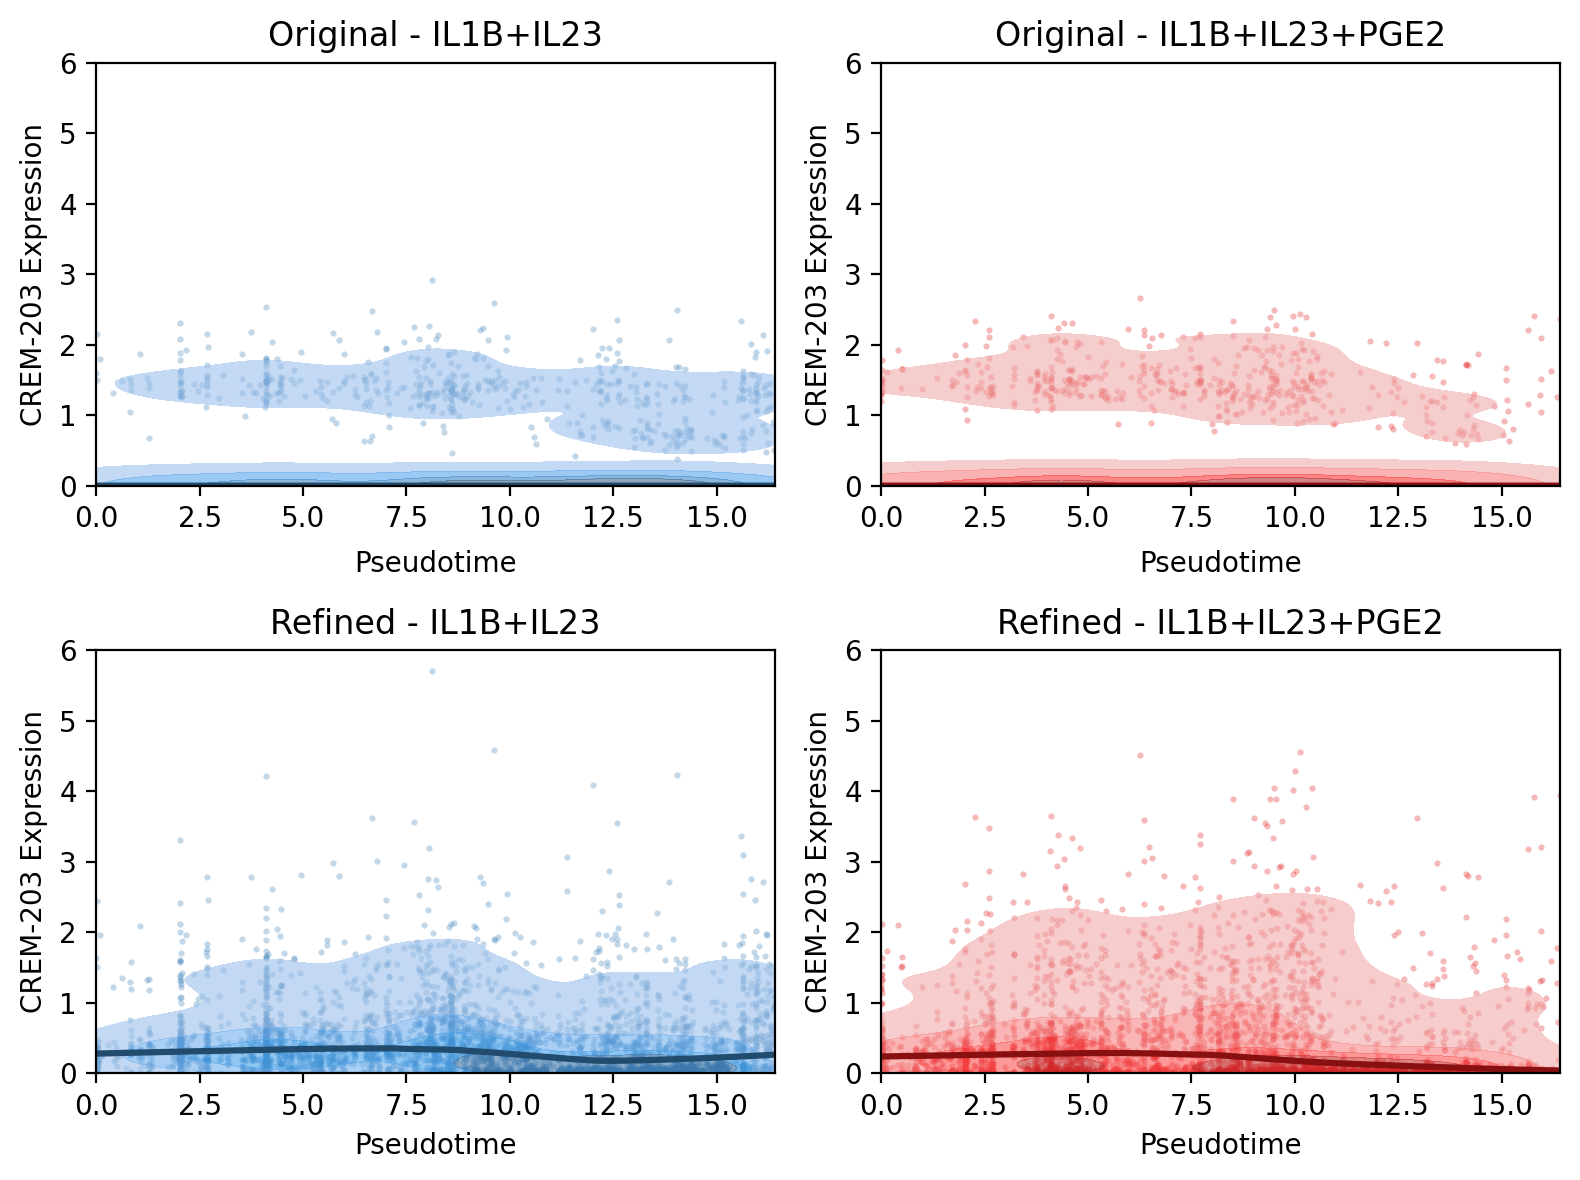

In [9]:
adata_raw, adata_refined, pseudotime_metadata = read_data('4fc', '20230614')

# subset where condition_time ends with "PGE2"
adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time ends with "PGE2"
adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))

2fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


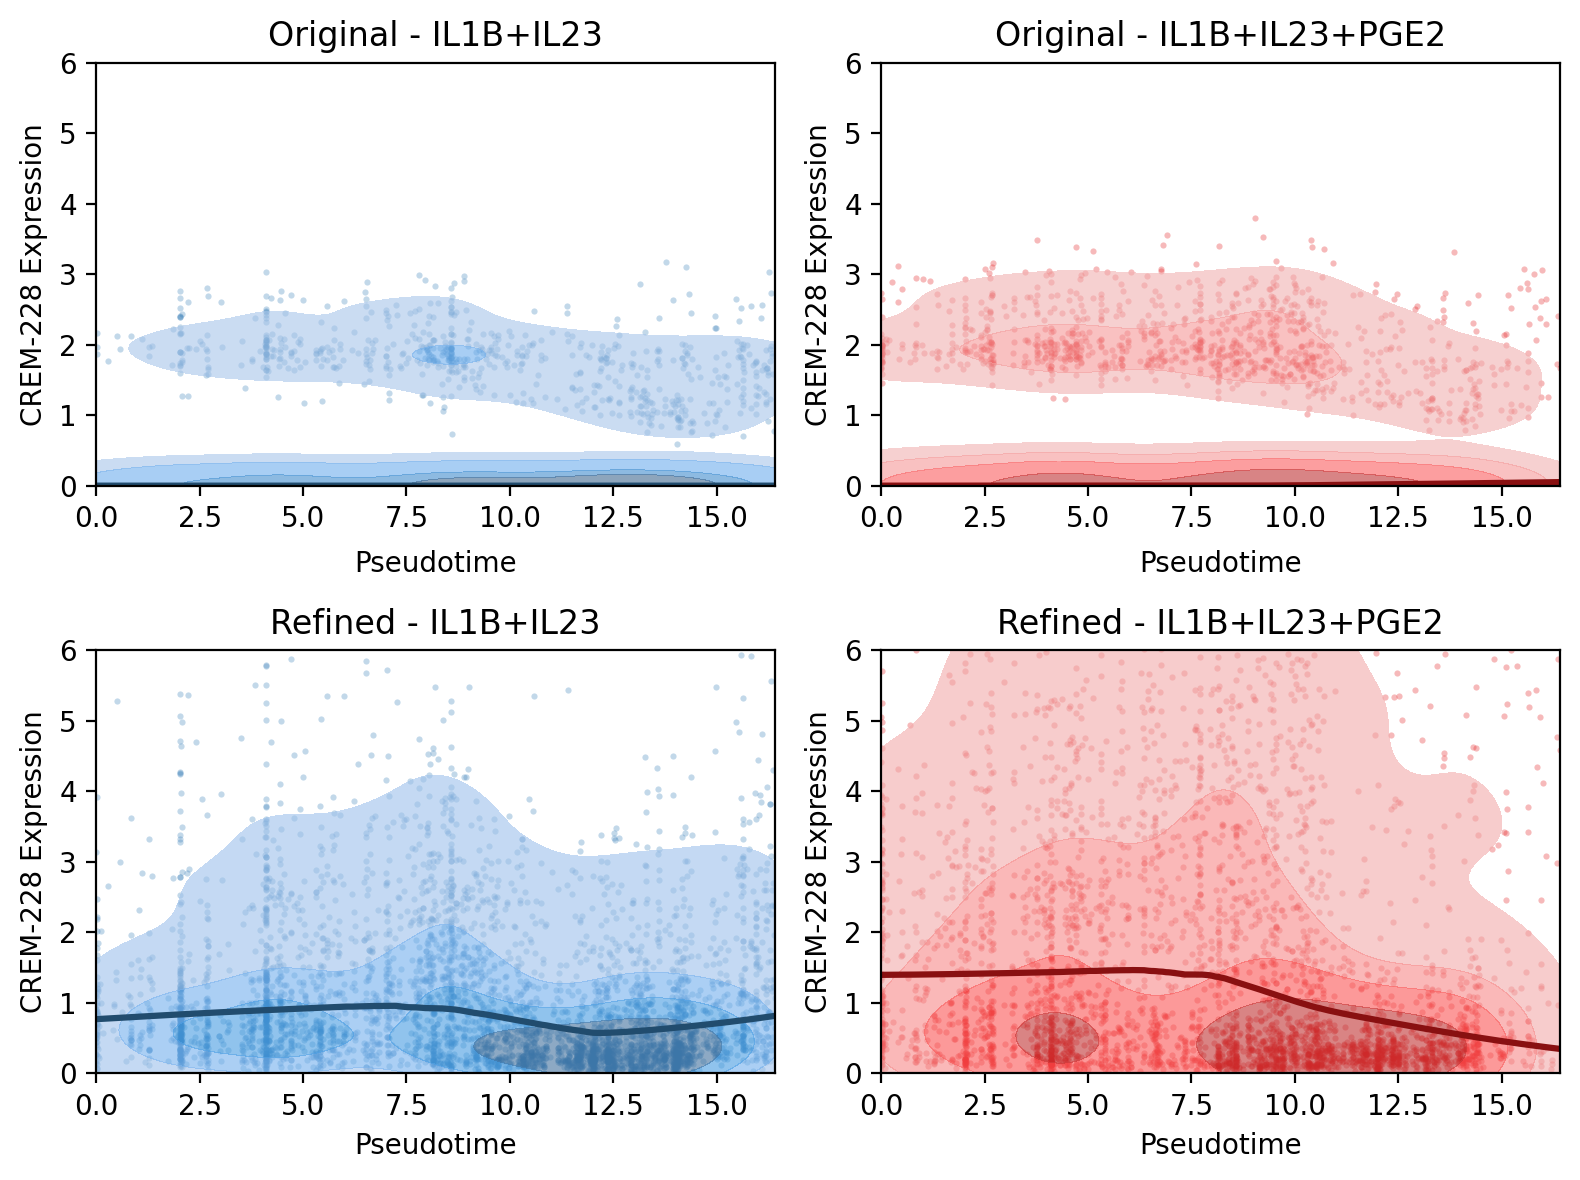

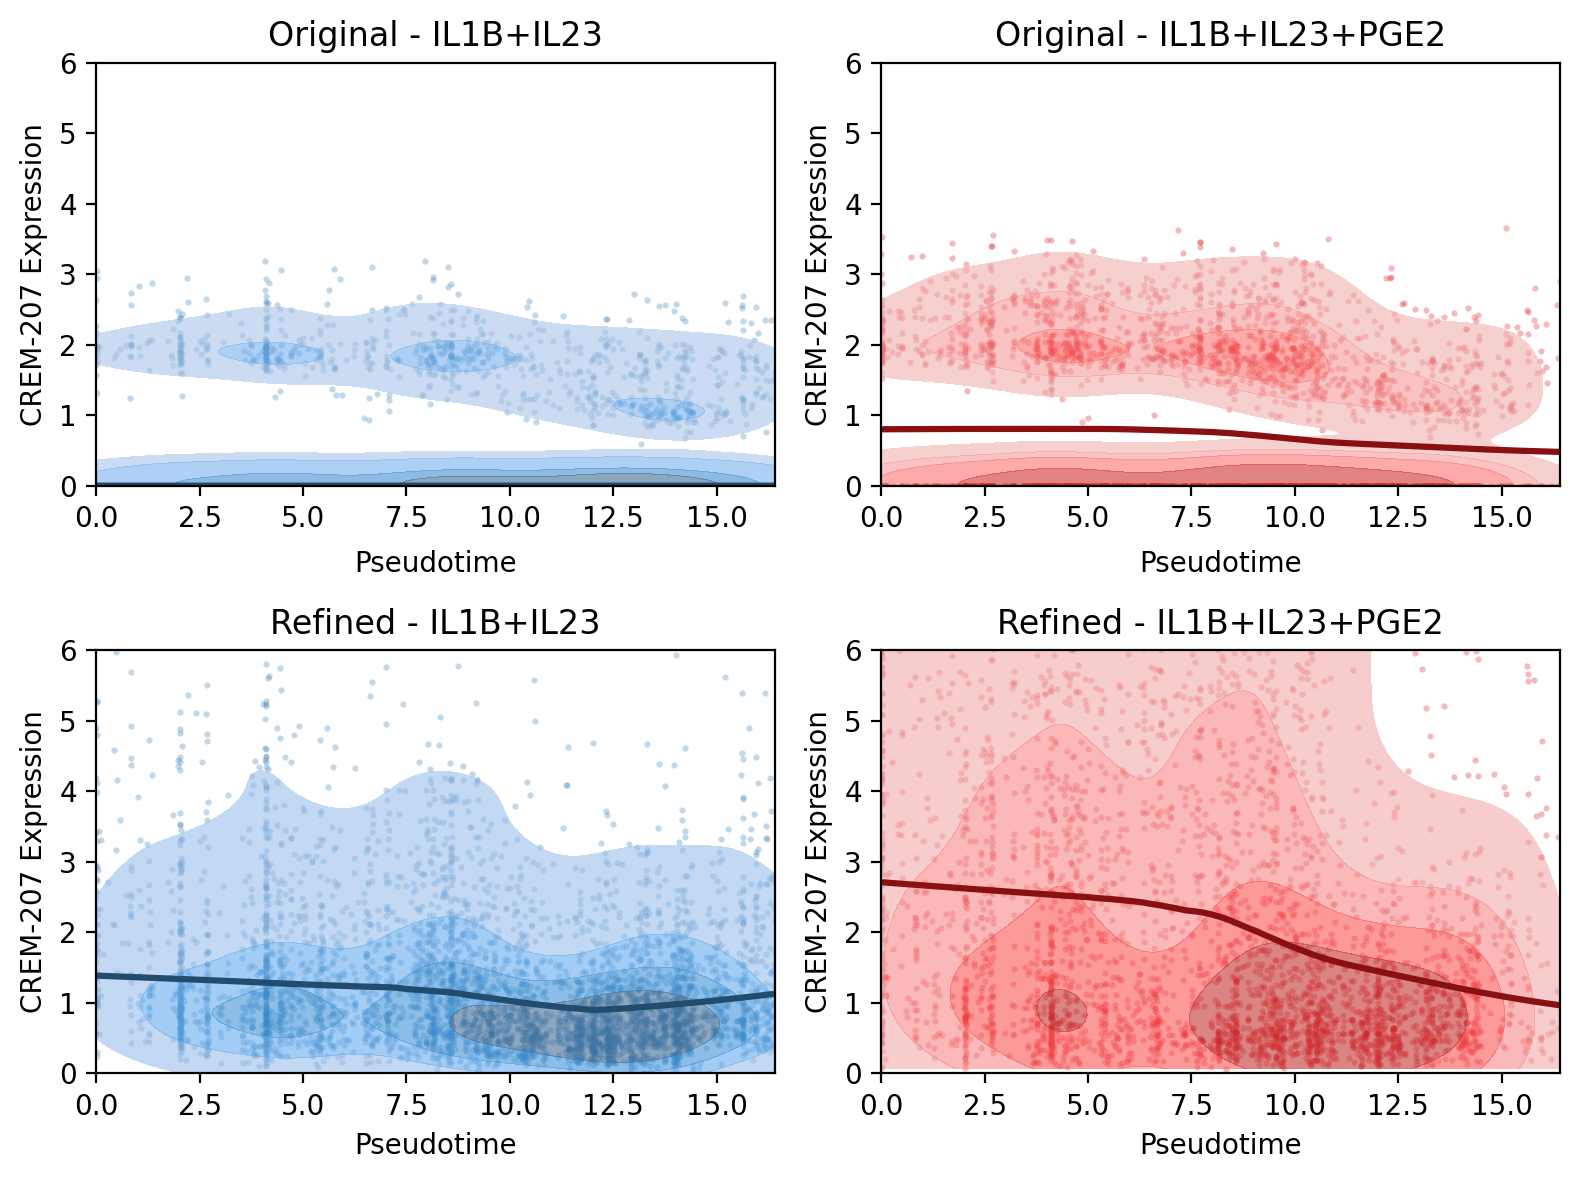

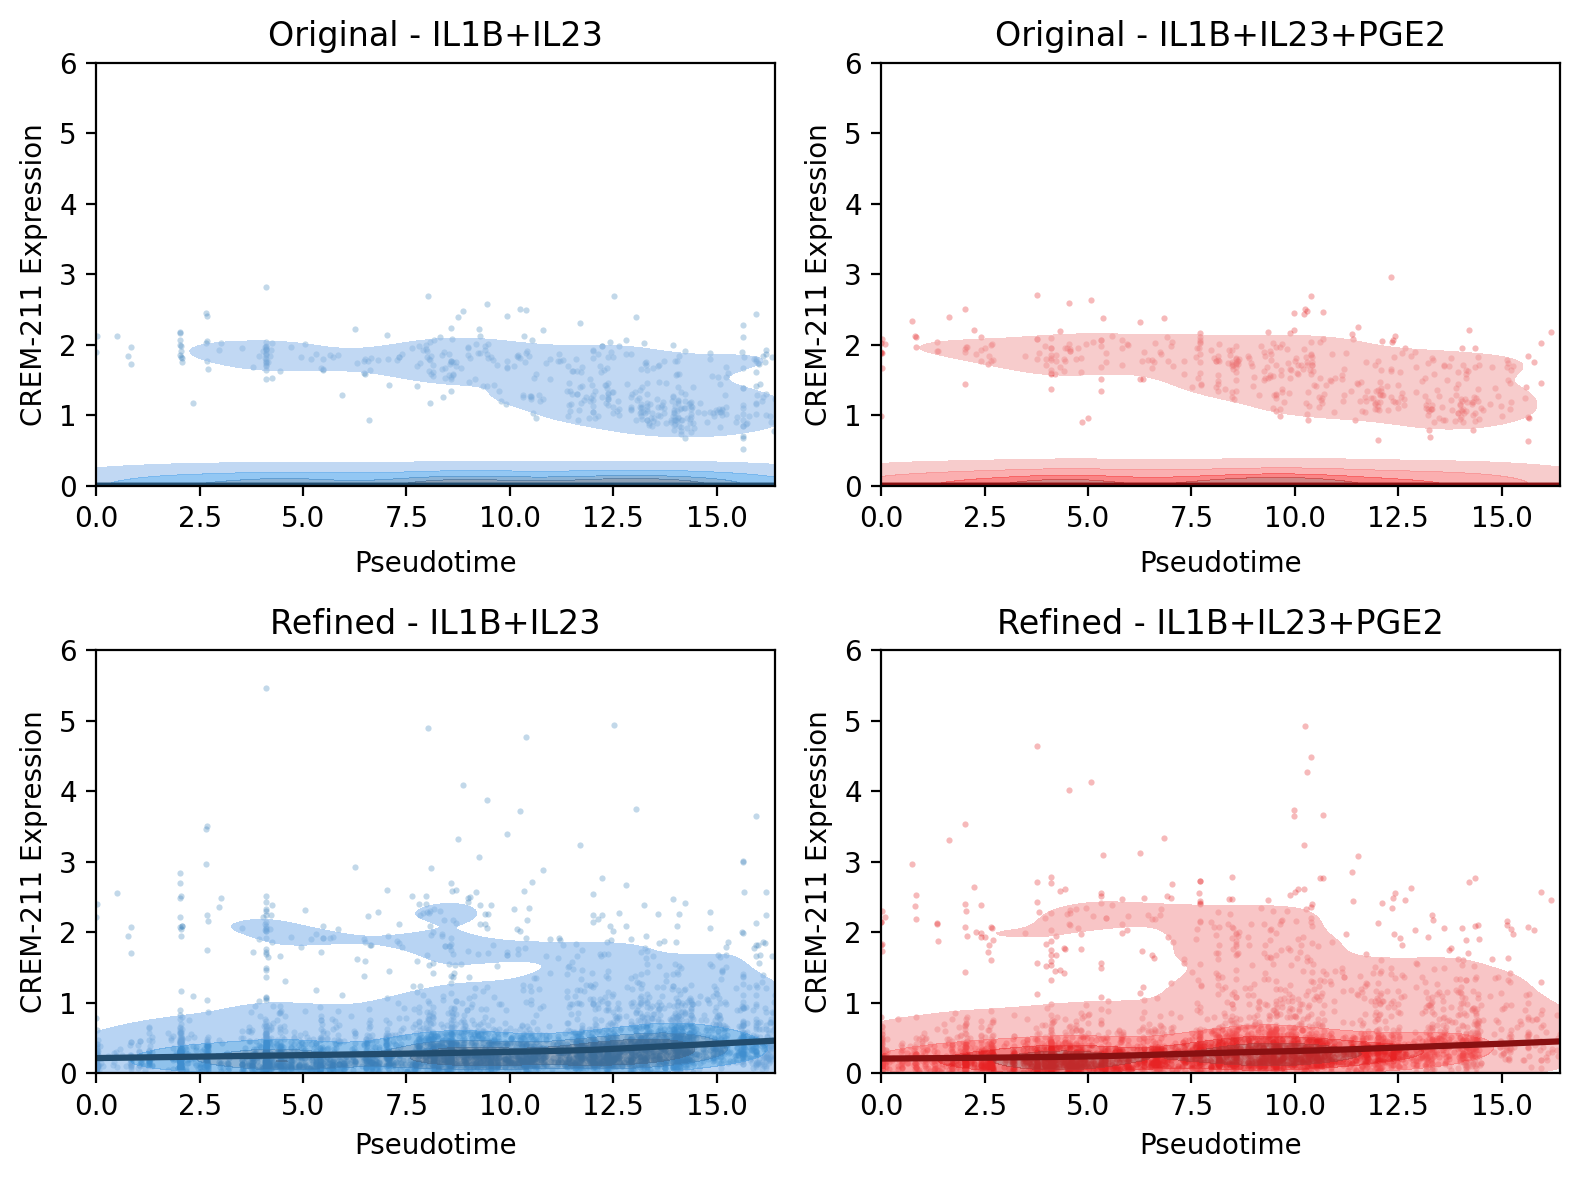

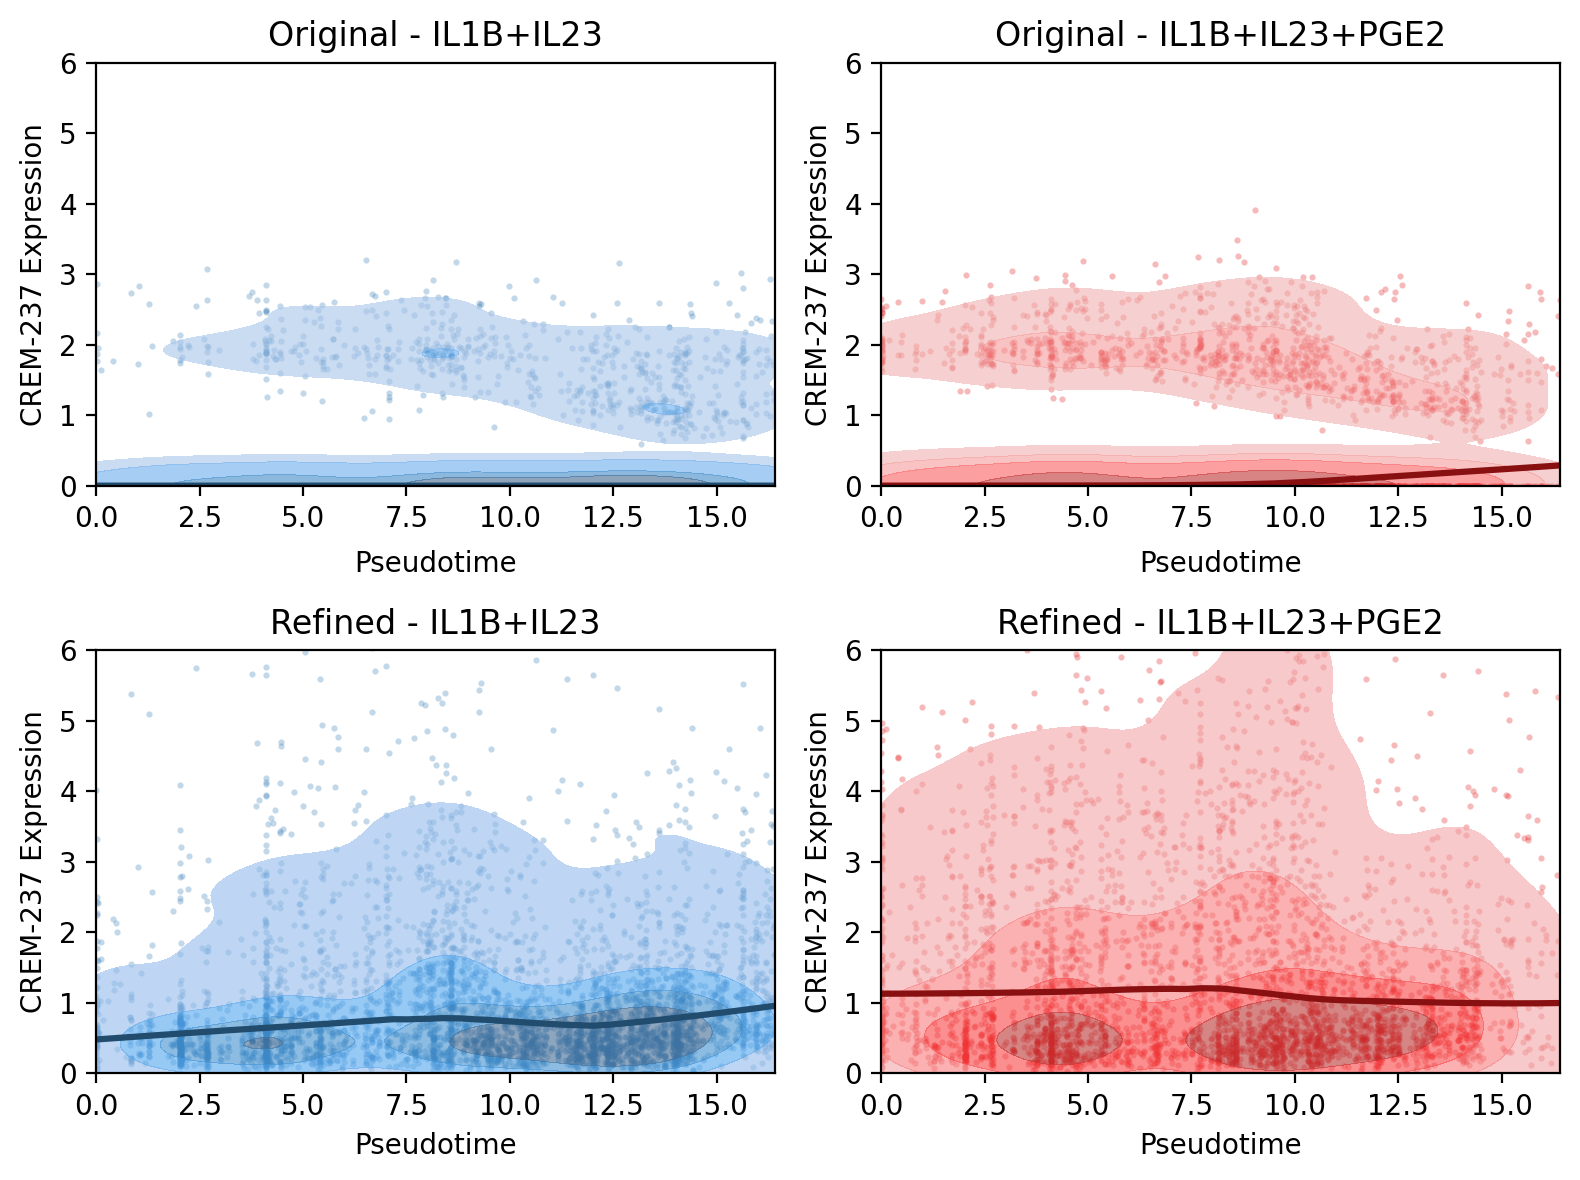

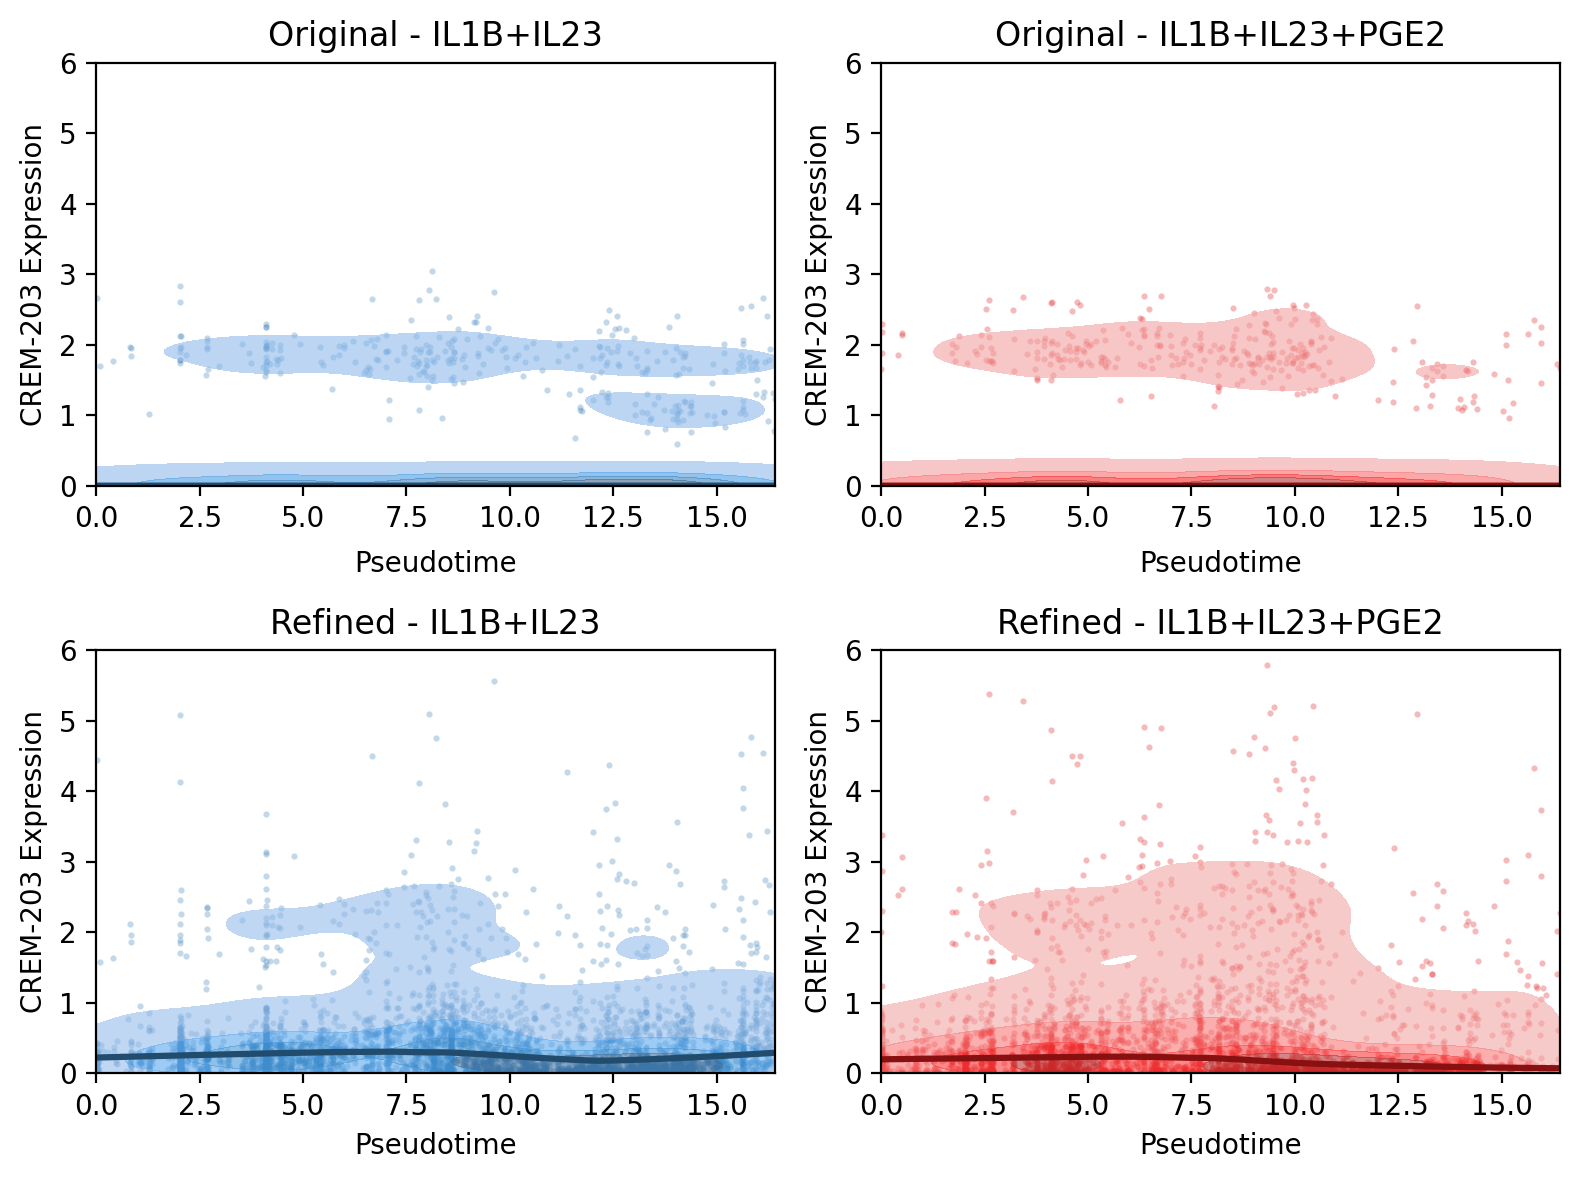

In [10]:
adata_raw, adata_refined, pseudotime_metadata = read_data('2fc', '20230614')

# subset where condition_time ends with "PGE2"
adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time ends with "PGE2"
adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

# subset where condition_time does NOT end with "PGE2"
adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))

Pseudotime DTU

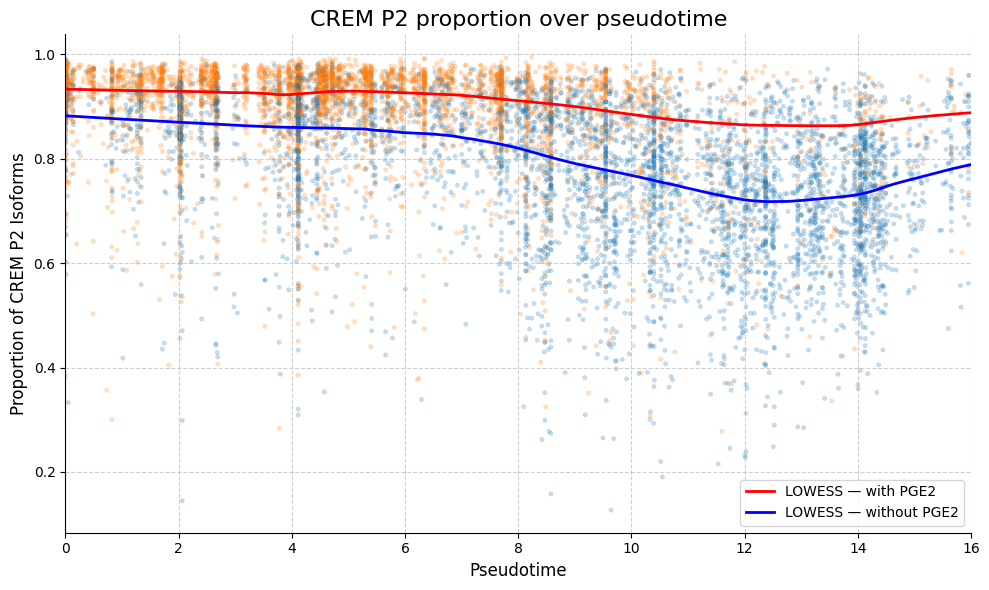

In [11]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import sparse

CREM_P1 = ['CREM-204','CREM-210','CREM-211','CREM-212','CREM-218','CREM-229','CREM-240']
CREM_P2 = ['CREM-203','CREM-207','CREM-224','CREM-225','CREM-228','CREM-230','CREM-236','CREM-237','CREM-238','CREM-242']
CREM_NA = ['CREM-205','CREM-208','CREM-209','CREM-217','CREM-226','CREM-227','CREM-233','CREM-239','CREM-241','CREM-247','CREM-248']

def read_data(flowcell, dataset):
    adata_raw = sc.read_h5ad(f"./{dataset}_new/transcript_raw_{flowcell}.h5ad")
    adata_refined = sc.read_h5ad(f"./{dataset}_new/transcript_new_{flowcell}.h5ad")
    pseudotime_metadata = pd.read_csv(f'./{dataset}_new/meta_data_pseudotime.csv', index_col=0)

    keep = adata_raw.obs.index.isin(pseudotime_metadata['cell_names'])
    adata_raw = adata_raw[keep].copy()
    sc.pp.normalize_total(adata_raw, target_sum=1e4)
    sc.pp.log1p(adata_raw)

    pt = pseudotime_metadata.set_index('cell_names')['pseudotime']
    adata_raw.obs['pseudotime'] = pt.loc[adata_raw.obs.index].values

    keep2 = adata_refined.obs.index.isin(pseudotime_metadata['cell_names'])
    adata_refined = adata_refined[keep2].copy()
    adata_refined.obs['pseudotime'] = pt.loc[adata_refined.obs.index].values

    return adata_raw, adata_refined, pseudotime_metadata

def _sum_group(adata_in, names):
    keep = [g for g in names if g in adata_in.var_names]
    if not keep:
        return np.zeros(adata_in.n_obs, dtype=float)
    X = adata_in[:, keep].X
    if sparse.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    else:
        return np.asarray(X.sum(axis=1)).ravel()

def add_crem_p2_prop(adata_in):
    p1 = _sum_group(adata_in, CREM_P1)
    p2 = _sum_group(adata_in, CREM_P2)
    na = _sum_group(adata_in, CREM_NA)
    tot = p1 + p2 + na
    tot_safe = np.where(tot == 0, 1.0, tot)
    adata_in.obs['CREM_P2_proportion'] = p2 / tot_safe

def plot_proportion_lowess(adata_no_pge2, adata_pge2, title='CREM P2 proportion over pseudotime'):
    combined = pd.concat([
        adata_no_pge2.obs[['pseudotime','CREM_P2_proportion','condition']],
        adata_pge2.obs[['pseudotime','CREM_P2_proportion','condition']]
    ], axis=0, ignore_index=True).dropna(subset=['pseudotime','CREM_P2_proportion'])

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=combined.sample(frac=1.0, random_state=1),
        x='pseudotime', y='CREM_P2_proportion',
        hue='condition', alpha=0.25, s=10, edgecolor=None, legend=False
    )

    colors = {'without PGE2': 'blue', 'with PGE2': 'red'}
    for cond, df in combined.groupby('condition'):
        if len(df) < 5:
            continue
        df = df.sort_values('pseudotime')
        lo = lowess(df['CREM_P2_proportion'], df['pseudotime'], frac=0.3, return_sorted=True)
        plt.plot(lo[:,0], lo[:,1], lw=2, label=f'LOWESS — {cond}', color=colors.get(cond, None))

    plt.title(title, fontsize=16)
    plt.xlabel('Pseudotime', fontsize=12)
    plt.ylabel('Proportion of CREM P2 Isoforms', fontsize=12)
    plt.xlim([0, 16])
    plt.grid(True, linestyle='--', alpha=0.6)
    sns.despine()
    plt.legend()
    plt.tight_layout()
    plt.show()

adata_raw, adata_refined, pseudotime_metadata = read_data('8fc', '20230426')
adata = adata_refined  # pick refined data

ct = adata.obs['condition_time'].astype('string')
is_pge2 = ct.fillna('').str.endswith('PGE2')
mask_pge2 = is_pge2.to_numpy(dtype=bool)
adata_pge2    = adata[mask_pge2, :].copy()
adata_no_pge2 = adata[~mask_pge2, :].copy()
adata_pge2.obs['condition']    = 'with PGE2'
adata_no_pge2.obs['condition'] = 'without PGE2'

# add CREM proportions
for ad in (adata_no_pge2, adata_pge2):
    add_crem_p2_prop(ad)

plot_proportion_lowess(adata_no_pge2, adata_pge2)
